# Day 4 — Market Probability Inspection

Goal: inspect the output of Day 4 market-implied probability processing.

This notebook does not create production data transformations.

Production logic lives in:

- `src/fbsystem/features/market_probs.py`

Build script:

- `scripts/build_market_probabilities.py`

Input:

- `data/processed/matches_with_market_probs.parquet`

Expected report:

- `outputs/evaluation/market_probability_report.csv`

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/processed/matches_with_market_probs.parquet")
REPORT_PATH = Path("../outputs/evaluation/market_probability_report.csv")

assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"
assert REPORT_PATH.exists(), f"Missing file: {REPORT_PATH}"

In [3]:
df = pd.read_parquet(DATA_PATH)
report = pd.read_csv(REPORT_PATH)

df.shape

(14597, 26)

In [4]:
df.columns.tolist()

['match_id',
 'match_date',
 'season',
 'season_start_year',
 'source_country',
 'source_league_code',
 'league',
 'home_team',
 'away_team',
 'home_goals',
 'away_goals',
 'full_time_result',
 'home_odds',
 'draw_odds',
 'away_odds',
 'odds_source',
 'source_season',
 'source_layout',
 'source_file',
 'raw_home_implied_prob',
 'raw_draw_implied_prob',
 'raw_away_implied_prob',
 'market_overround',
 'market_home_prob',
 'market_draw_prob',
 'market_away_prob']

In [5]:
[
    "raw_home_implied_prob",
    "raw_draw_implied_prob",
    "raw_away_implied_prob",
    "market_overround",
    "market_home_prob",
    "market_draw_prob",
    "market_away_prob",
]

['raw_home_implied_prob',
 'raw_draw_implied_prob',
 'raw_away_implied_prob',
 'market_overround',
 'market_home_prob',
 'market_draw_prob',
 'market_away_prob']

In [6]:
report

,metric,value
0,n_rows,1.459700e+04
1,mean_market_overround,1.053213e+00
2,min_market_overround,9.286797e-01
3,max_market_overround,1.092216e+00
4,mean_market_home_prob,4.390632e-01
5,mean_market_draw_prob,2.485916e-01
6,mean_market_away_prob,3.123452e-01
7,min_market_prob_sum,1.000000e+00
8,max_market_prob_sum,1.000000e+00
9,max_abs_market_prob_sum_error,2.220446e-16


In [7]:
market_prob_cols = [
    "market_home_prob",
    "market_draw_prob",
    "market_away_prob",
]

prob_sums = df[market_prob_cols].sum(axis=1)

prob_sums.describe()

count    1.459700e+04
mean     1.000000e+00
std      8.422845e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [8]:
max_abs_error = (prob_sums - 1.0).abs().max()
max_abs_error

np.float64(2.220446049250313e-16)

In [9]:
df["market_overround"].describe()

count    14597.000000
mean         1.053213
std          0.011126
min          0.928680
25%          1.043928
50%          1.051649
75%          1.060744
max          1.092216
Name: market_overround, dtype: float64

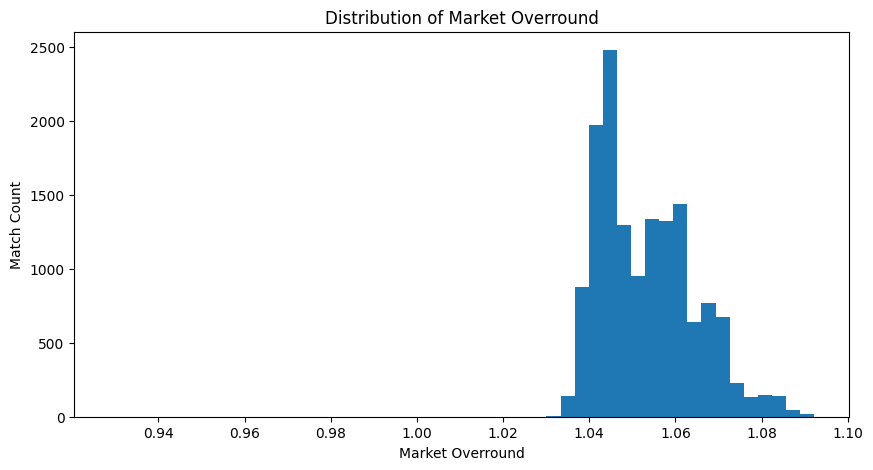

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["market_overround"], bins=50)
plt.title("Distribution of Market Overround")
plt.xlabel("Market Overround")
plt.ylabel("Match Count")
plt.show()

In [11]:
df[market_prob_cols].describe()

,market_home_prob,market_draw_prob,market_away_prob
count,14597.000000,14597.000000,14597.000000
mean,0.439063,0.248592,0.312345
std,0.181640,0.050397,0.164099
min,0.026144,0.050090,0.020201
25%,0.306843,0.222807,0.190222
50%,0.426299,0.260912,0.287532
75%,0.564008,0.283494,0.408801
max,0.926290,0.558036,0.901335


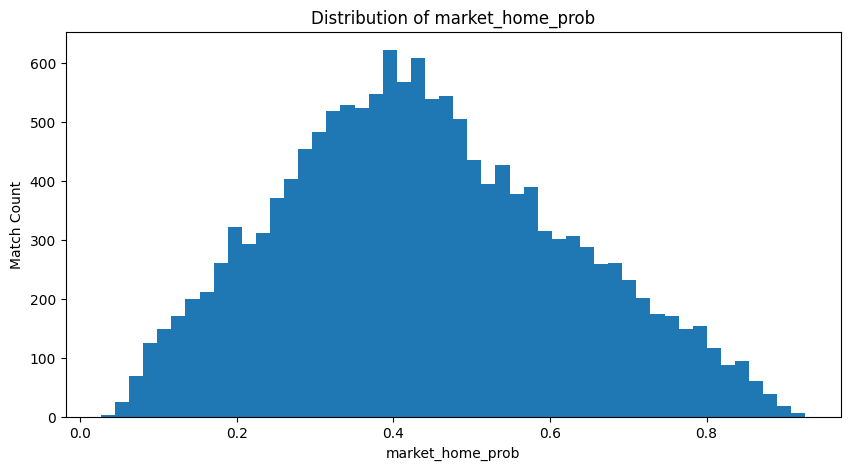

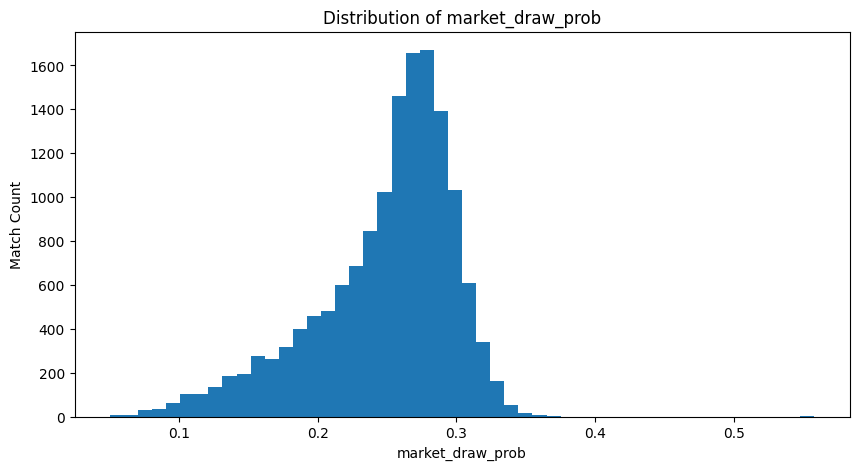

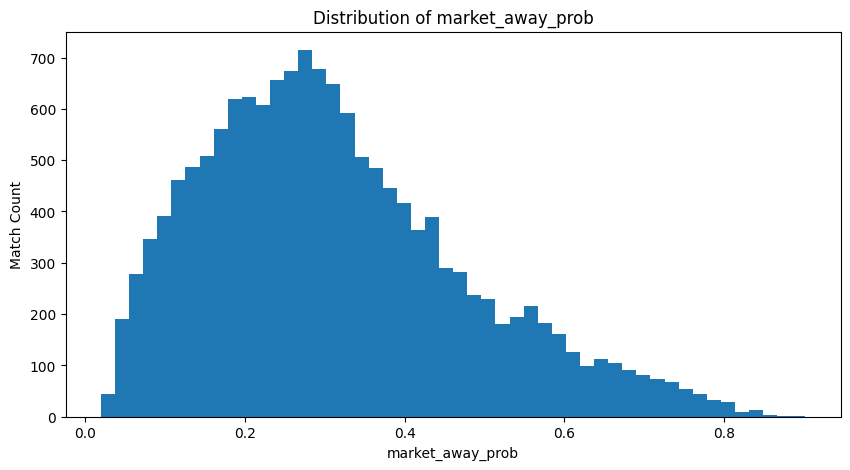

In [12]:
for col in market_prob_cols:
    plt.figure(figsize=(10, 5))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Match Count")
    plt.show()

In [14]:
display_cols = [
    "match_date",
    "season",
    "source_country",
    "source_league_code",
    "home_team",
    "away_team",
    "home_odds",
    "draw_odds",
    "away_odds",
    "raw_home_implied_prob",
    "raw_draw_implied_prob",
    "raw_away_implied_prob",
    "market_overround",
    "market_home_prob",
    "market_draw_prob",
    "market_away_prob",
]

df[display_cols].head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,home_odds,draw_odds,away_odds,raw_home_implied_prob,raw_draw_implied_prob,raw_away_implied_prob,market_overround,market_home_prob,market_draw_prob,market_away_prob
0,2021-07-23,2021-2022,belgium,B1,Standard,Genk,3.20,3.75,2.08,0.312500,0.266667,0.480769,1.059936,0.294829,0.251588,0.453583
1,2021-07-23,2021-2022,mexico,MEX,Queretaro,Club America,3.67,3.16,2.09,0.272480,0.316456,0.478469,1.067404,0.255273,0.296472,0.448255
2,2021-07-24,2021-2022,belgium,B1,Kortrijk,Seraing,1.78,3.73,4.34,0.561798,0.268097,0.230415,1.060309,0.529843,0.252848,0.217309
3,2021-07-24,2021-2022,belgium,B1,Oostende,Charleroi,2.25,3.41,3.10,0.444444,0.293255,0.322581,1.060280,0.419176,0.276583,0.304241
4,2021-07-24,2021-2022,belgium,B1,Oud-Heverlee Leuven,Waregem,1.97,3.95,3.35,0.507614,0.253165,0.298507,1.059286,0.479204,0.238995,0.281801
5,2021-07-24,2021-2022,mexico,MEX,Juarez,Toluca,2.49,3.20,2.79,0.401606,0.312500,0.358423,1.072529,0.374448,0.291367,0.334185
6,2021-07-24,2021-2022,mexico,MEX,Necaxa,Santos Laguna,2.81,3.11,2.54,0.355872,0.321543,0.393701,1.071116,0.332244,0.300195,0.367561
7,2021-07-24,2021-2022,mexico,MEX,Pachuca,Club Leon,2.26,3.39,3.01,0.442478,0.294985,0.332226,1.069689,0.413651,0.275767,0.310582
8,2021-07-25,2021-2022,belgium,B1,Anderlecht,St. Gilloise,2.04,3.33,3.73,0.490196,0.300300,0.268097,1.058593,0.463064,0.283679,0.253257
9,2021-07-25,2021-2022,belgium,B1,Club Brugge,Eupen,1.21,6.61,11.89,0.826446,0.151286,0.084104,1.061837,0.778318,0.142476,0.079206


In [15]:
season_summary = (
    df.groupby("season")
    .agg(
        matches=("match_id", "count"),
        mean_overround=("market_overround", "mean"),
        mean_home_prob=("market_home_prob", "mean"),
        mean_draw_prob=("market_draw_prob", "mean"),
        mean_away_prob=("market_away_prob", "mean"),
    )
    .reset_index()
)

season_summary

,season,matches,mean_overround,mean_home_prob,mean_draw_prob,mean_away_prob
0,2021-2022,3086,1.050301,0.438023,0.251232,0.310745
1,2022-2023,3086,1.050501,0.437348,0.249727,0.312924
2,2023-2024,3016,1.050263,0.443194,0.243483,0.313324
3,2024-2025,3016,1.051435,0.441308,0.247863,0.310829
4,2025-2026,2393,1.066428,0.434581,0.251078,0.314340


In [16]:
league_summary = (
    df.groupby(["source_country", "source_league_code"])
    .agg(
        matches=("match_id", "count"),
        mean_overround=("market_overround", "mean"),
        mean_home_prob=("market_home_prob", "mean"),
        mean_draw_prob=("market_draw_prob", "mean"),
        mean_away_prob=("market_away_prob", "mean"),
    )
    .reset_index()
    .sort_values(["source_country", "source_league_code"])
)

league_summary

,source_country,source_league_code,matches,mean_overround,mean_home_prob,mean_draw_prob,mean_away_prob
0,belgium,B1,1476,1.062249,0.433298,0.246719,0.319982
1,england,E0,1829,1.042505,0.439443,0.238699,0.321858
2,france,F1,1614,1.049131,0.435112,0.250419,0.314470
3,germany,D1,1467,1.046712,0.448944,0.235357,0.315699
4,italy,I1,1820,1.047977,0.426602,0.259673,0.313725
5,mexico,MEX,1640,1.071395,0.443740,0.261631,0.294629
6,netherlands,N1,1476,1.056067,0.455760,0.226000,0.318240
7,portugal,P1,1465,1.059974,0.426369,0.248689,0.324943
8,spain,SP1,1810,1.046567,0.443846,0.264599,0.291554


In [17]:
df[display_cols].sort_values("market_overround", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,home_odds,draw_odds,away_odds,raw_home_implied_prob,raw_draw_implied_prob,raw_away_implied_prob,market_overround,market_home_prob,market_draw_prob,market_away_prob
14432,2026-03-09,2025-2026,mexico,MEX,Club Tijuana,Santos Laguna,1.53,4.11,5.12,0.653595,0.243309,0.195312,1.092216,0.598411,0.222766,0.178822
14385,2026-03-07,2025-2026,mexico,MEX,Mazatlan FC,Club Leon,3.02,3.43,2.13,0.331126,0.291545,0.469484,1.092155,0.303186,0.266945,0.429869
14417,2026-03-08,2025-2026,mexico,MEX,Tigres UANL,Monterrey,1.83,3.51,3.84,0.546448,0.284900,0.260417,1.091765,0.500518,0.260954,0.238528
14288,2026-02-28,2025-2026,mexico,MEX,Club Tijuana,UNAM Pumas,2.13,3.41,3.04,0.469484,0.293255,0.328947,1.091686,0.430054,0.268626,0.301320
14386,2026-03-07,2025-2026,mexico,MEX,Necaxa,UNAM Pumas,2.83,3.45,2.23,0.353357,0.289855,0.448430,1.091642,0.323693,0.265522,0.410785
14287,2026-02-28,2025-2026,mexico,MEX,Atl. San Luis,Puebla,2.08,3.32,3.23,0.480769,0.301205,0.309598,1.091572,0.440438,0.275937,0.283625
14323,2026-03-01,2025-2026,mexico,MEX,Club America,Tigres UANL,2.13,3.12,3.32,0.469484,0.320513,0.301205,1.091201,0.430245,0.293725,0.276031
14324,2026-03-01,2025-2026,mexico,MEX,Club Leon,Necaxa,2.06,3.41,3.20,0.485437,0.293255,0.312500,1.091192,0.444868,0.268748,0.286384
14325,2026-03-01,2025-2026,mexico,MEX,Monterrey,Cruz Azul,2.60,3.39,2.43,0.384615,0.294985,0.411523,1.091123,0.352495,0.270350,0.377155
14291,2026-02-28,2025-2026,mexico,MEX,Queretaro,Santos Laguna,1.88,3.51,3.65,0.531915,0.284900,0.273973,1.090788,0.487643,0.261188,0.251169


In [18]:
df[display_cols].sort_values("market_overround", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,home_odds,draw_odds,away_odds,raw_home_implied_prob,raw_draw_implied_prob,raw_away_implied_prob,market_overround,market_home_prob,market_draw_prob,market_away_prob
14432,2026-03-09,2025-2026,mexico,MEX,Club Tijuana,Santos Laguna,1.53,4.11,5.12,0.653595,0.243309,0.195312,1.092216,0.598411,0.222766,0.178822
14385,2026-03-07,2025-2026,mexico,MEX,Mazatlan FC,Club Leon,3.02,3.43,2.13,0.331126,0.291545,0.469484,1.092155,0.303186,0.266945,0.429869
14417,2026-03-08,2025-2026,mexico,MEX,Tigres UANL,Monterrey,1.83,3.51,3.84,0.546448,0.284900,0.260417,1.091765,0.500518,0.260954,0.238528
14288,2026-02-28,2025-2026,mexico,MEX,Club Tijuana,UNAM Pumas,2.13,3.41,3.04,0.469484,0.293255,0.328947,1.091686,0.430054,0.268626,0.301320
14386,2026-03-07,2025-2026,mexico,MEX,Necaxa,UNAM Pumas,2.83,3.45,2.23,0.353357,0.289855,0.448430,1.091642,0.323693,0.265522,0.410785
14287,2026-02-28,2025-2026,mexico,MEX,Atl. San Luis,Puebla,2.08,3.32,3.23,0.480769,0.301205,0.309598,1.091572,0.440438,0.275937,0.283625
14323,2026-03-01,2025-2026,mexico,MEX,Club America,Tigres UANL,2.13,3.12,3.32,0.469484,0.320513,0.301205,1.091201,0.430245,0.293725,0.276031
14324,2026-03-01,2025-2026,mexico,MEX,Club Leon,Necaxa,2.06,3.41,3.20,0.485437,0.293255,0.312500,1.091192,0.444868,0.268748,0.286384
14325,2026-03-01,2025-2026,mexico,MEX,Monterrey,Cruz Azul,2.60,3.39,2.43,0.384615,0.294985,0.411523,1.091123,0.352495,0.270350,0.377155
14291,2026-02-28,2025-2026,mexico,MEX,Queretaro,Santos Laguna,1.88,3.51,3.65,0.531915,0.284900,0.273973,1.090788,0.487643,0.261188,0.251169


In [19]:
df[display_cols].sort_values("market_overround", ascending=True).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,home_odds,draw_odds,away_odds,raw_home_implied_prob,raw_draw_implied_prob,raw_away_implied_prob,market_overround,market_home_prob,market_draw_prob,market_away_prob
12307,2025-08-16,2025-2026,spain,SP1,Mallorca,Barcelona,8.70,5.79,1.56,0.114943,0.172712,0.641026,0.928680,0.123770,0.185975,0.690255
6023,2023-05-21,2022-2023,england,E0,Man City,Chelsea,1.62,4.19,5.85,0.617284,0.238663,0.170940,1.026888,0.601121,0.232414,0.166464
1432,2021-12-16,2021-2022,england,E0,Chelsea,Everton,1.21,6.99,16.25,0.826446,0.143062,0.061538,1.031046,0.801561,0.138754,0.059685
2235,2022-03-06,2021-2022,england,E0,Man City,Man United,1.42,5.03,7.75,0.704225,0.198807,0.129032,1.032065,0.682346,0.192631,0.125023
3416,2022-08-27,2022-2023,england,E0,Man City,Crystal Palace,1.20,7.51,15.24,0.833333,0.133156,0.065617,1.032106,0.807411,0.129014,0.063576
2202,2022-03-05,2021-2022,england,E0,Liverpool,West Ham,1.26,6.67,11.24,0.793651,0.149925,0.088968,1.032544,0.768636,0.145200,0.086164
3494,2022-08-31,2022-2023,england,E0,Liverpool,Newcastle,1.29,6.22,10.29,0.775194,0.160772,0.097182,1.033147,0.750323,0.155614,0.094064
1433,2021-12-16,2021-2022,england,E0,Liverpool,Newcastle,1.11,10.85,24.82,0.900901,0.092166,0.040290,1.033357,0.871820,0.089191,0.038990
7062,2023-11-04,2023-2024,england,E0,Man City,Bournemouth,1.10,11.54,26.43,0.909091,0.086655,0.037836,1.033582,0.879554,0.083840,0.036606
4528,2023-01-13,2022-2023,italy,I1,Napoli,Juventus,2.13,3.37,3.74,0.469484,0.296736,0.267380,1.033599,0.454222,0.287090,0.258688


In [20]:
(df["market_overround"] < 1.0).sum()

np.int64(1)